# Superstore Project 
Dataset containing Sales & Profits of a Superstore

-- Business Statistics & Insights | Master in Business Analytics & AI

The goal is to use the Superstore Sales dataset (9,994 transactions, 2014–2017) not just to complete the assignment, but to produce work that directly maps to the five skill areas in the target role. Each section below defines the analysis, the method, the business framing, and the free tool to use.

* Dataset: https://www.kaggle.com/datasets/vivek468/superstore-dataset-final

### Task 2. Descriptive Stats

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_parquet('../data/processed/superstore_clean.parquet')
print(f"{df.shape[0]} rows, {df.shape[1]} columns")

9994 rows, 29 columns


In [ ]:
# Check the dataframe stats
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit,Profit Margin,Delivery Days,Year,Quarter,Month
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,55190.379428,229.858001,3.789574,0.156203,28.656896,0.120314,3.958175,2015.722233,2.882329,7.809686
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000,-2.750000,0.000000,2014.000000,1.000000,1.000000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750,0.075000,3.000000,2015.000000,2.000000,5.000000
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500,0.270000,4.000000,2016.000000,3.000000,9.000000
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000,0.362500,5.000000,2017.000000,4.000000,11.000000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000,0.500000,7.000000,2017.000000,4.000000,12.000000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108,0.466754,1.747567,1.123555,1.058086,3.284654


#### Task 2.A - Central Tendency of the dataframe

In [3]:
metrics = ['Sales', 'Profit', 'Quantity', 'Discount' ]

central_tendency = pd.DataFrame({
    'Mean': df[metrics].mean(),
    'Median': df[metrics].median(),
    'Mode': df[metrics].mode().iloc[0]
}).round(2)

print(central_tendency)

            Mean  Median   Mode
Sales     229.86   54.49  12.96
Profit     28.66    8.67   0.00
Quantity    3.79    3.00   3.00
Discount    0.16    0.20   0.00


In [ ]:
# look at the gap between mean and median
for col in ['Sales', 'Profit']:
    mean = df[col].mean()
    median = df[col].median() # median of a datawet is the value that lies exactly in the middle when the data has been ordered
    print(f"{col}: mean={mean:.2f}, median={median:.2f}, gap={((mean-median)/median*100):.1f}%")

Sales: mean=229.86, median=54.49, gap=321.8%
Profit: mean=28.66, median=8.67, gap=230.7%


The mean transaction value ($229) substantially exceeds the median ($54), indicating a right-skewed distribution driven by a minority of high-value orders. The median is therefore the more representative measure of central tendency for Sales. For Discount, the mode of 0.0 confirms that the majority of transactions carry no discount, with discounted orders representing a distinct subset of the data rather than standard practice

#### Task 2.B - Dispersion

In [6]:
# CV (Coefficient of Variation) is the std as % of the mean
# With it we can compare variability across variables that have different units and scales

dispersion = pd.DataFrame({
    'Min':    df[metrics].min(),
    'Max':    df[metrics].max(),
    'Range':  df[metrics].max() - df[metrics].min(),
    'Std Dev': df[metrics].std(),
    'Variance': df[metrics].var(),
    'IQR':    df[metrics].quantile(0.75) - df[metrics].quantile(0.25),
    'CV (%)': (df[metrics].std() / df[metrics].mean() * 100),  # Coefficient of Variation
}).round(2)

print(dispersion)

              Min       Max     Range  Std Dev   Variance     IQR  CV (%)
Sales        0.44  22638.48  22638.04   623.25  388434.46  192.66  271.14
Profit   -6599.98   8399.98  14999.95   234.26   54877.80   27.64  817.47
Quantity     1.00     14.00     13.00     2.23       4.95    3.00   58.72
Discount     0.00      0.80      0.80     0.21       0.04    0.20  132.17


In [14]:
print("Top discount values by frequency:")
print(df['Discount'].value_counts().head(10).sort_index())

print(f"\nSkewness of Discount: {df['Discount'].skew():.3f}")

Top discount values by frequency:
Discount
0.00    4798
0.10      94
0.15      52
0.20    3657
0.30     227
0.40     206
0.50      66
0.60     138
0.70     418
0.80     300
Name: count, dtype: int64

Skewness of Discount: 1.684


Discount does not follow a continuous distribution. Instead, it takes a small set of discrete values (0%, 20%, 40%, 60%, 80%), with 0% and 20% accounting for the vast majority of transactions. This discrete, tiered structure indicates company-defined promotional levels rather than individually negotiated discounts. Mean and median both equal 0.2, reflecting the dominance of the 20% tier among discounted orders.

* Sales and Profit display high coefficients of variation (appr. 271% and 817% respectively), indicating substantial dispersion relative to their averages values.
* This reflects the heterogeneous nature of the transactions mix: from a small office supply orders to large furniture purchases, with ranges from very small purchases ($0.44) to large orders exceding $22,000.
* Profitability is even more volatile, with values spanning from losses of nearly $6,600 to gains over $8,400.
* The interquartile range (IQR) for Profit ($20.67) suggests that the middle 50% of transactions generate relatively modest profits, while the extreme tails capture unusually profitable orders as well as significant losses, likely influenced by heavy discounting and differences in product mix.
* The high variability in both Sales and Profit indicates that aggregate performance is driven by a relatively small number of exceptionally large or highly profitable transactions.

In [15]:
print(f"Profit CV: {df['Profit'].std() / df['Profit'].mean() * 100:.0f}%")
print(f"For comparison, Sales CV: {df['Sales'].std() / df['Sales'].mean() * 100:.0f}%")
print(f"\nProfit ranges from ${df['Profit'].min():,.0f} to ${df['Profit'].max():,.0f}")
print(f"But 50% of orders generate profit between ${df['Profit'].quantile(0.25):,.0f} and ${df['Profit'].quantile(0.75):,.0f}")

Profit CV: 817%
For comparison, Sales CV: 271%

Profit ranges from $-6,600 to $8,400
But 50% of orders generate profit between $2 and $29


#### Task 2.C - Shape of Distributions

Histograms with KDE
* A histogram with a Kernel Density Estimate (KDE) overlays a smooth, continuous probability curve onto a discrete bar chart

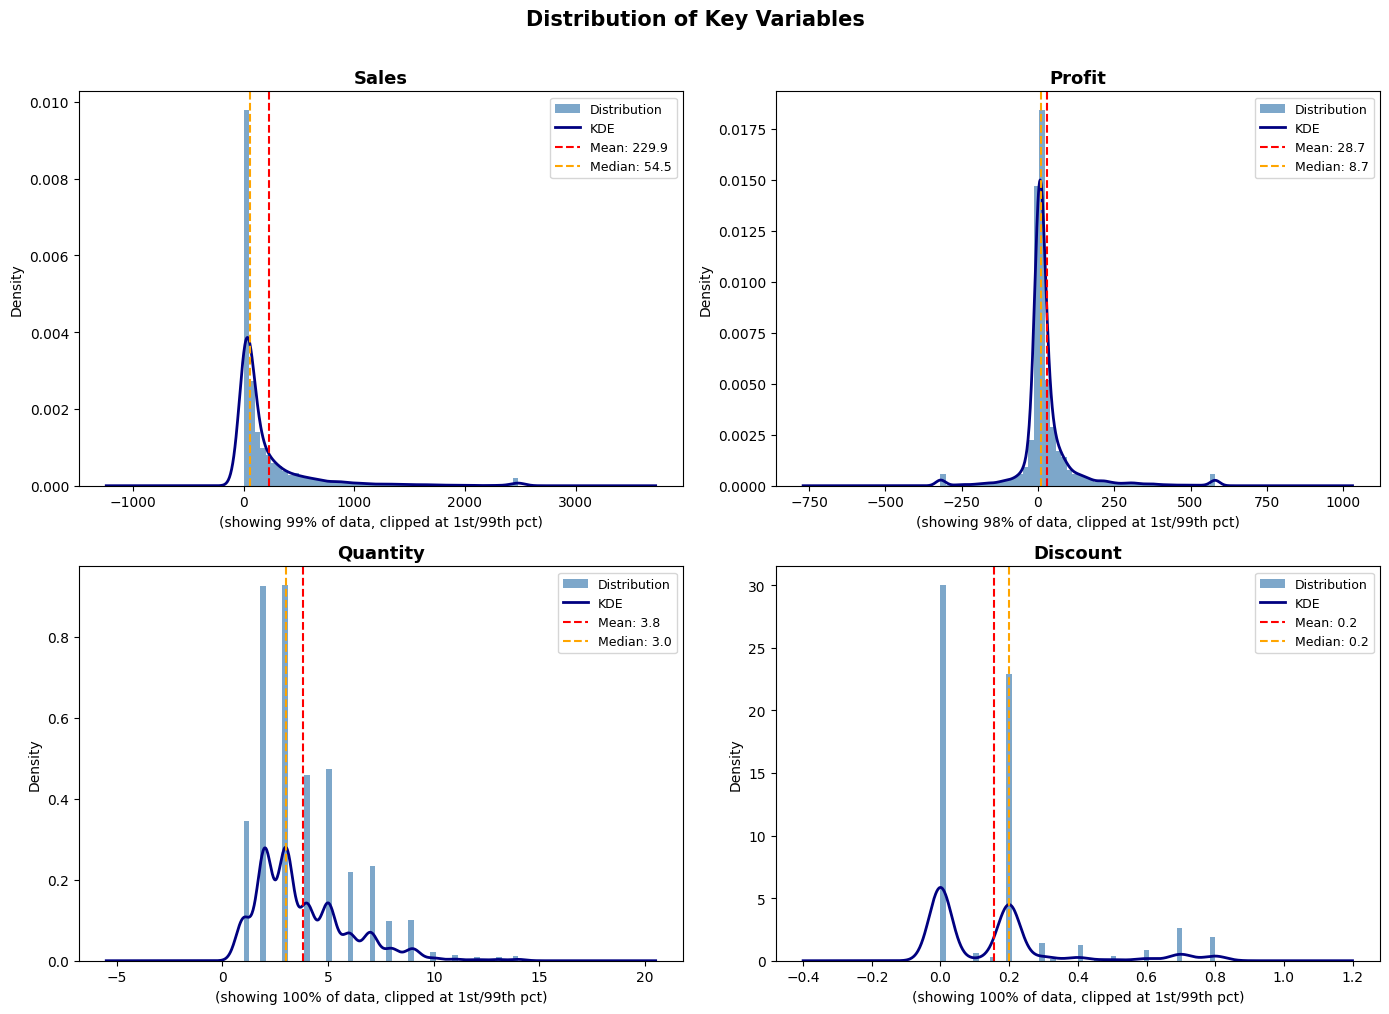

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Define display limits per variable (clip outliers for readability)
clip_limits = {
    'Sales':    (0, df['Sales'].quantile(0.99)),
    'Profit':   (df['Profit'].quantile(0.01), df['Profit'].quantile(0.99)),
    'Quantity': (0, 15),
    'Discount': (-0.05, 0.85)
}

for i, col in enumerate(metrics):
    lo, hi = clip_limits[col]
    data = df[col].clip(lo, hi)

    axes[i].hist(data, bins=50, color='steelblue', alpha=0.7, 
                 density=True, label='Distribution')
    data.plot.kde(ax=axes[i], color='navy', linewidth=2, label='KDE')
    axes[i].axvline(df[col].mean(),   color='red',    linestyle='--', 
                    linewidth=1.5, label=f'Mean: {df[col].mean():.1f}')
    axes[i].axvline(df[col].median(), color='orange', linestyle='--', 
                    linewidth=1.5, label=f'Median: {df[col].median():.1f}')
    axes[i].set_title(col, fontsize=13, fontweight='bold')
    axes[i].legend(fontsize=9)
    axes[i].set_ylabel('Density')

    # Note in subtitle if clipped
    pct_shown = ((df[col] >= lo) & (df[col] <= hi)).mean() * 100
    axes[i].set_xlabel(f'(showing {pct_shown:.0f}% of data, clipped at 1st/99th pct)')

plt.suptitle('Distribution of Key Variables', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../output/images/02_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

Skeness and Kurtosis

In [9]:
shape = pd.DataFrame({
    'Skewness':         df[metrics].skew(),
    'Kurtosis':         df[metrics].kurtosis(),
    'Interpretation':   [
        'Right-skewed - few very large orders',
        'Right-skewed - losses in tail',
        'Slightly righ-skiwed - bulk orders',
        'Left-skewed - most orders have 0% or low discount'
    ]
}).round(3)

print(shape)

          Skewness  Kurtosis  \
Sales       12.973   305.312   
Profit       7.561   397.189   
Quantity     1.279     1.992   
Discount     1.684     2.410   

                                             Interpretation  
Sales                  Right-skewed - few very large orders  
Profit                        Right-skewed - losses in tail  
Quantity                 Slightly righ-skiwed - bulk orders  
Discount  Left-skewed - most orders have 0% or low discount  


* Sales — strongly right-skewed. The clearest signal: mean ($229.9) is more than 4× the median ($54.5). That gap only happens when a long right tail pulls the mean upward. Most transactions are small, but a few very large orders distort the average.
* Profit — strongly right-skewed, but with a heavy left tail too. Mean ($28.7) > median ($8.7) confirms right skew. However, Profit is unusual because it also has extreme negative values. The skewness number will be positive, but the chart shows it's almost symmetric visually — just with very fat tails on both sides. The technical term is leptokurtic: thin peak, heavy tails.
* Quantity — mildly right-skewed. Mean (3.8) slightly above median (3.0). Most orders are 1–5 units, with a thin tail trailing to 14. The skew is modest.
* Discount — approximately symmetric, but multimodal. Mean = Median = 0.2, so skewness will be close to zero. This doesn't mean the distribution is normal — it's discrete with five distinct spikes. Symmetric ≠ normal.

In [17]:
from scipy.stats import kurtosis

kurtosis(df["Profit"], fisher=False)

# If kurtosis > 3 (or excess kurtosis > 0), then the claim is statistically supported.

np.float64(399.9892286014973)

Summary: 
* Sales and Profit are both strongly positively skewed, as evidenced by the mean exceeding the median and the presence of long right tails. 
* This indicates that a relatively small number of high-value transactions exert a disproportionate influence on average performance ( Profit exhibits leptokurtosis). 
* Profit additionally shows a pronounced central concentration with substantial tails on both the positive and negative sides, reflecting the coexistence of highly profitable orders and significant losses within the portfolio. 
* Quantity is only mildly right-skewed, consistent with the predominance of small orders.
* Discount is distinctly non-normal and multimodal, with discrete peaks at common discount levels that reflect a structured pricing policy rather than a naturally occurring statistical distribution. 
* Given the strong skewness and outliers in Sales and Profit, the median provides a more representative measure of typical transaction performance than the mean

#### Task 2.D - Comparative Analysis

Comparison 1 - By Region